# Week 1 — Real Estate Listing Data Exploration

This notebook explores `data/processed/listing_sample.csv`, the sample of real-estate listings extracted from the `rets_property` table.

### Goals
- Validate the sample dataset and identify missing or unusual values.
- Understand distributions of price, bedrooms, bathrooms, and locations.
- Analyze listing-remark lengths and common language.
- Extract common words and bigrams that can inform the real-estate taxonomy.
- Identify patterns useful for downstream entity extraction, query parsing, semantic search, intent classification, and taxonomy coverage.


In [4]:
from pathlib import Path
from collections import Counter
import re

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("../data/processed/listing_sample.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} was not found. Run scripts/data_loading.py from the project root first."
    )

df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.head()


Rows: 1,000
Columns: 7


,L_ListingID,L_Address,L_City,beds,baths,price,remarks
0,1183875749,10353 Miller Avenue,Cupertino,7,6.0,3095000,"Excellent opportunity for savvy homeowner, mul..."
1,1190122787,1212 Via Montoya,Camarillo,2,2.0,539950,"Welcome to this gorgeous, one-of-a-kind upgrad..."
2,1190321159,15723 Bonsallo,Gardena,4,2.0,848000,Welcome to this beautifully updated home in Ga...
3,1181615148,1719 Calatina Dr,Pomona,4,2.0,650000,Welcome to this charming single-family home in...
4,1159059243,155 Waterford Circle,Rancho Mirage,4,5.0,3175000,"South-facing on over half an acre, this contem..."


## 1. Dataset structure

First, inspect column names, data types, and a small sample of the extracted listings.


In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

display(df.sample(min(5, len(df)), random_state=42))


Columns:
['L_ListingID', 'L_Address', 'L_City', 'beds', 'baths', 'price', 'remarks']

Data types:


,dtype
L_ListingID,int64
L_Address,str
L_City,str
beds,int64
baths,float64
price,int64
remarks,str


,L_ListingID,L_Address,L_City,beds,baths,price,remarks
521,1148907357,426 E Orchard Street,Rialto,3,2.0,575000,BACK ON THE MARKET! Buyer withdrew before sho...
737,1159179275,1471 Cherokee,Yucca Valley,2,2.0,340000,"Bring the horses, goats and chickens! This lov..."
740,1182273274,235 E M,Colton,1,1.0,379000,Come check out this cute single family home. T...
660,1175202998,127 Lanzon,Irvine,5,6.0,7480000,View ! View ! View ! Perched at the pinnacle o...
411,1151910508,16765 Charro Road,Lake Elsinore,5,5.0,1399888,Located just beyond the Orange County border i...


## 2. Data quality

The Week 1 deliverable calls for 500–1,000 listing remarks. The extraction query also requires remarks longer than 50 characters. This section checks those requirements and summarizes missing values and duplicates.


In [6]:
quality = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True),
})

display(quality)

print(f"Duplicate rows: {df.duplicated().sum():,}")

if "L_ListingID" in df.columns:
    print(f"Duplicate listing IDs: {df['L_ListingID'].duplicated().sum():,}")

if "remarks" in df.columns:
    remark_lengths = df["remarks"].fillna("").astype(str).str.len()
    print(f"Minimum remark length: {remark_lengths.min():,}")
    print(f"Median remark length: {remark_lengths.median():,.0f}")
    print(f"Maximum remark length: {remark_lengths.max():,}")
    print(f"Remarks > 50 characters: {(remark_lengths > 50).mean():.1%}")


,missing_count,missing_percent,unique_values
L_ListingID,0,0.0,1000
L_Address,2,0.2,998
L_City,3,0.3,342
beds,0,0.0,10
baths,0,0.0,14
price,0,0.0,628
remarks,0,0.0,1000


Duplicate rows: 0
Duplicate listing IDs: 0
Minimum remark length: 85
Median remark length: 1,242
Maximum remark length: 3,997
Remarks > 50 characters: 100.0%


## 3. Numeric summary

Review the central tendency and spread of bedrooms, bathrooms, and listing prices. Invalid or missing values are coerced to `NaN` for analysis rather than causing the notebook to fail.


In [7]:
numeric_candidates = ["beds", "baths", "price"]
available_numeric = [c for c in numeric_candidates if c in df.columns]

for col in available_numeric:
    df[col] = pd.to_numeric(df[col], errors="coerce")

if available_numeric:
    display(df[available_numeric].describe().T)
else:
    print("No expected numeric columns were found.")


,count,mean,std,min,25%,50%,75%,max
beds,1000.0,3.253,1.310996e+00,0.0,2.0,3.0,4.0,9.0
baths,1000.0,2.827,1.526893e+00,0.0,2.0,3.0,3.0,14.0
price,1000.0,1613806.303,3.282341e+06,26500.0,549000.0,788162.0,1399000.0,49800000.0


## 4. Price distribution

Real-estate prices often contain large outliers, so both the full distribution and the 99th-percentile-trimmed distribution are useful.


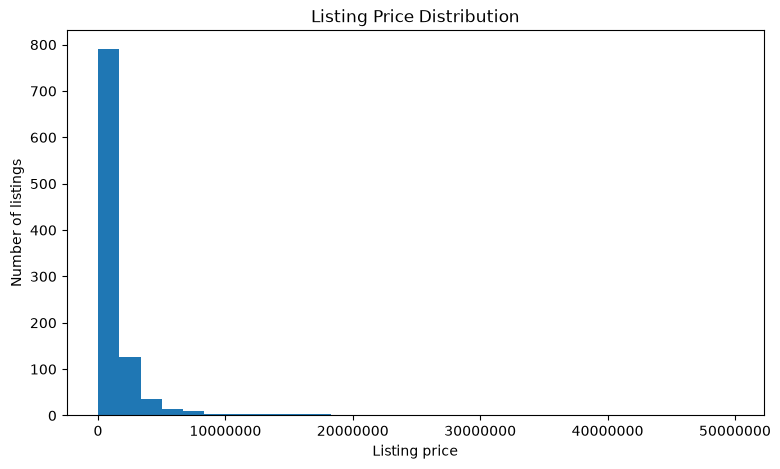

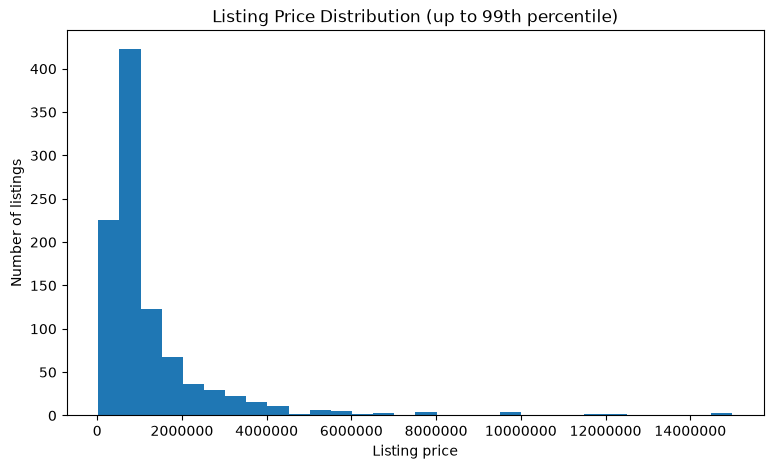

Median price: $788,162
99th percentile: $15,000,000


In [8]:
if "price" in df.columns:
    prices = df["price"].dropna()
    prices = prices[prices >= 0]

    if not prices.empty:
        plt.figure(figsize=(9, 5))
        plt.hist(prices, bins=30)
        plt.xlabel("Listing price")
        plt.ylabel("Number of listings")
        plt.title("Listing Price Distribution")
        plt.ticklabel_format(style="plain", axis="x")
        plt.show()

        cutoff = prices.quantile(0.99)
        trimmed = prices[prices <= cutoff]

        plt.figure(figsize=(9, 5))
        plt.hist(trimmed, bins=30)
        plt.xlabel("Listing price")
        plt.ylabel("Number of listings")
        plt.title("Listing Price Distribution (up to 99th percentile)")
        plt.ticklabel_format(style="plain", axis="x")
        plt.show()

        print(f"Median price: ${prices.median():,.0f}")
        print(f"99th percentile: ${cutoff:,.0f}")
    else:
        print("No usable price values found.")
else:
    print("Column 'price' not found.")


## 5. Bedroom and bathroom distributions


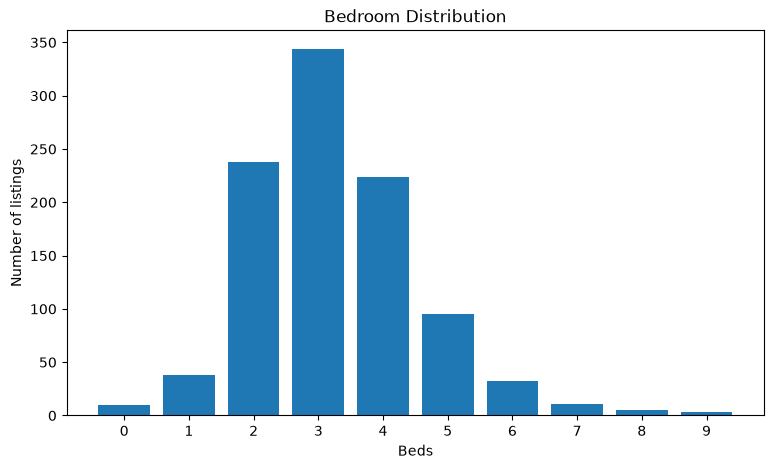

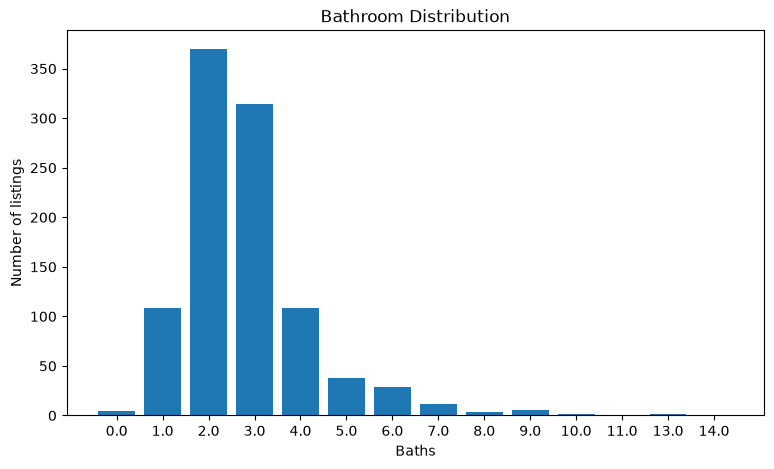

In [9]:
for col, title in [("beds", "Bedroom Distribution"), ("baths", "Bathroom Distribution")]:
    if col in df.columns:
        values = df[col].dropna()
        if not values.empty:
            counts = values.value_counts().sort_index()
            plt.figure(figsize=(9, 5))
            plt.bar(counts.index.astype(str), counts.values)
            plt.xlabel(col.capitalize())
            plt.ylabel("Number of listings")
            plt.title(title)
            plt.show()
        else:
            print(f"No usable values for {col}.")


## 6. Listings by city

This shows which cities are most represented in the random sample. Because the SQL query uses `ORDER BY RAND()`, these counts describe this sample rather than necessarily the complete database.


,listings
L_City,
Los Angeles,72
San Diego,30
San Jose,20
Oakland,17
Corona,13
Irvine,12
La Quinta,12
Lake Arrowhead,11
Palm Desert,10


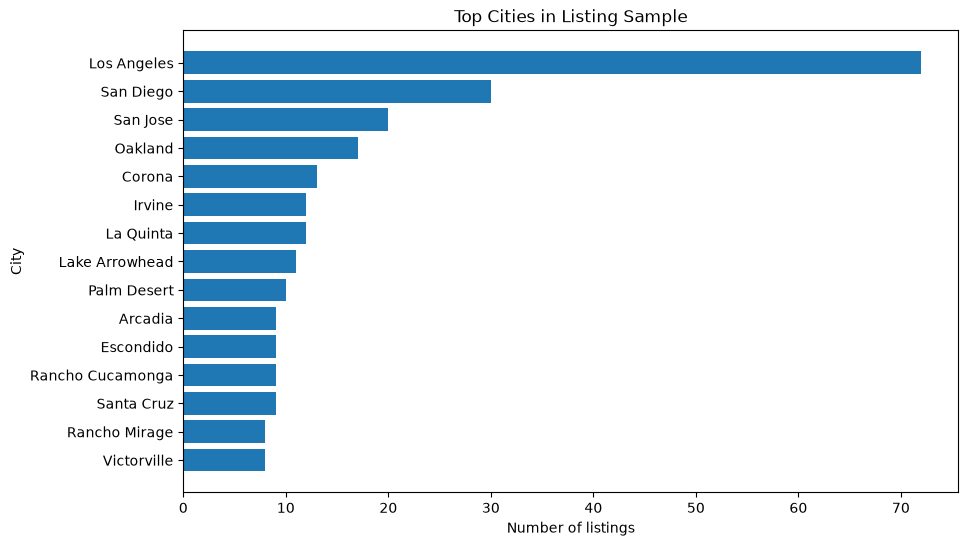

In [10]:
if "L_City" in df.columns:
    city_counts = df["L_City"].dropna().astype(str).str.strip().value_counts().head(15)
    display(city_counts.to_frame("listings"))

    if not city_counts.empty:
        plt.figure(figsize=(10, 6))
        plt.barh(city_counts.index[::-1], city_counts.values[::-1])
        plt.xlabel("Number of listings")
        plt.ylabel("City")
        plt.title("Top Cities in Listing Sample")
        plt.show()
else:
    print("Column 'L_City' not found.")


## 7. Listing remark length

Remark length is useful for understanding how much natural-language information is available per listing and for planning text preprocessing.


,count,mean,std,min,25%,50%,75%,max
remark_length,1000.0,1322.433,613.055113,85.0,890.75,1242.5,1670.25,3997.0
remark_word_count,1000.0,198.531,89.450245,15.0,135.75,185.0,251.00,603.0


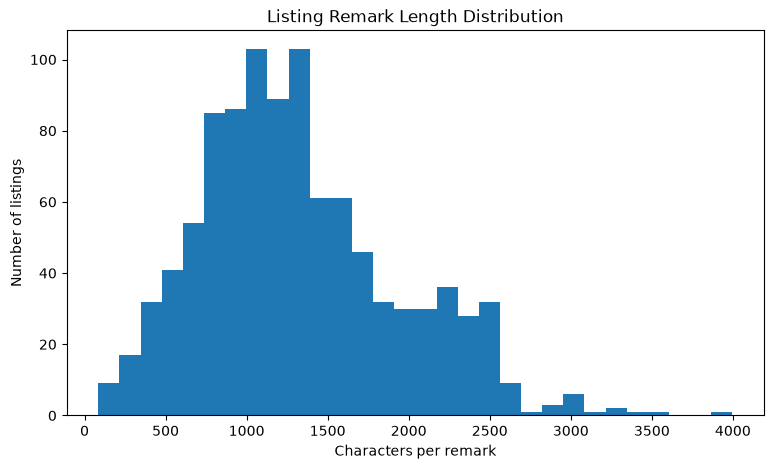

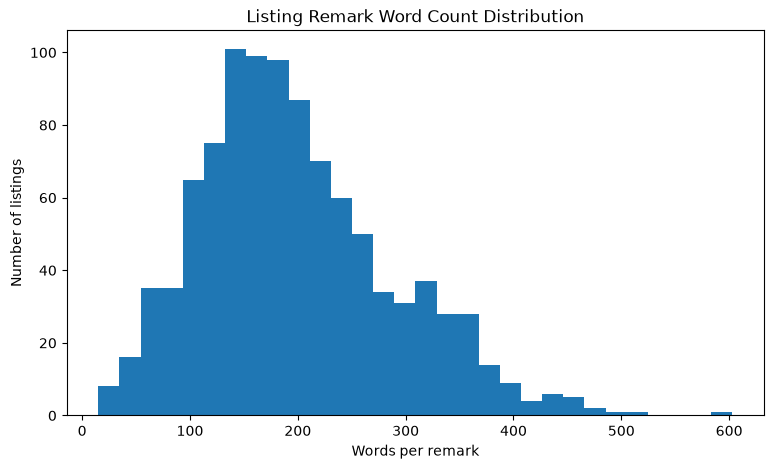

In [11]:
if "remarks" in df.columns:
    df["remark_length"] = df["remarks"].fillna("").astype(str).str.len()
    df["remark_word_count"] = df["remarks"].fillna("").astype(str).str.split().str.len()

    display(df[["remark_length", "remark_word_count"]].describe().T)

    plt.figure(figsize=(9, 5))
    plt.hist(df["remark_length"], bins=30)
    plt.xlabel("Characters per remark")
    plt.ylabel("Number of listings")
    plt.title("Listing Remark Length Distribution")
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.hist(df["remark_word_count"], bins=30)
    plt.xlabel("Words per remark")
    plt.ylabel("Number of listings")
    plt.title("Listing Remark Word Count Distribution")
    plt.show()
else:
    print("Column 'remarks' not found.")


## 8. Text preprocessing

For exploratory frequency analysis, convert remarks to lowercase alphabetic tokens and remove a small set of common English/real-estate boilerplate words. This is intentionally lightweight; production NLP preprocessing can be refined later.


In [12]:
STOPWORDS = {
    "the", "and", "a", "an", "to", "of", "in", "is", "with", "for", "this",
    "that", "on", "as", "at", "it", "from", "or", "be", "are", "has", "have",
    "your", "you", "its", "by", "all", "home", "property", "features", "offers"
}

def tokenize(text):
    tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", str(text).lower())
    return [token for token in tokens if len(token) > 2 and token not in STOPWORDS]

if "remarks" in df.columns:
    tokenized_remarks = df["remarks"].fillna("").map(tokenize)
    all_tokens = [token for tokens in tokenized_remarks for token in tokens]
    print(f"Total filtered tokens: {len(all_tokens):,}")
    print(f"Unique filtered tokens: {len(set(all_tokens)):,}")


Total filtered tokens: 138,596
Unique filtered tokens: 7,521


## 9. Most common words

Frequent words reveal recurring concepts in listing descriptions and can help identify candidate taxonomy terms.


,word,count
0,living,1858
1,room,1270
2,space,1121
3,kitchen,984
4,private,891
5,bedroom,789
6,dining,784
7,new,698
8,spacious,689
9,area,682


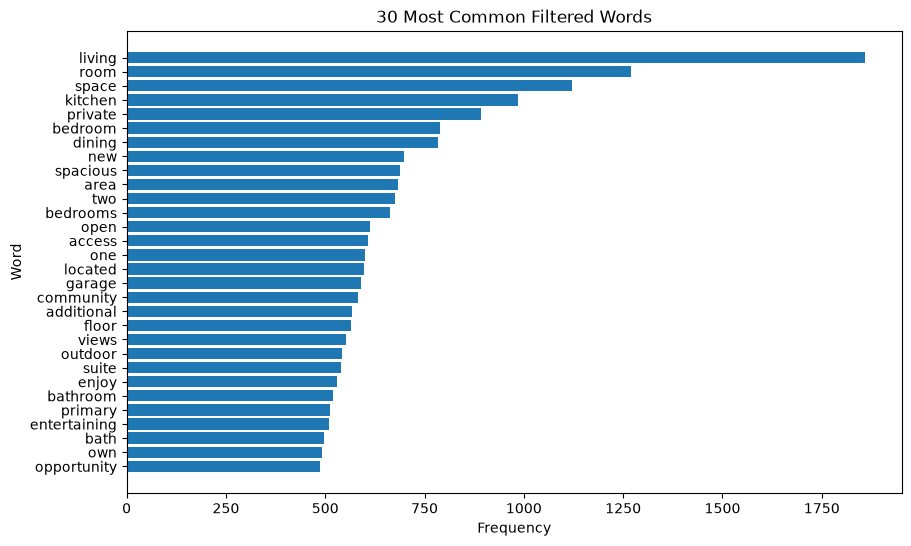

In [13]:
if "remarks" in df.columns:
    word_counts = Counter(all_tokens)
    top_words = pd.DataFrame(word_counts.most_common(30), columns=["word", "count"])
    display(top_words)

    if not top_words.empty:
        plt.figure(figsize=(10, 6))
        plt.barh(top_words["word"][::-1], top_words["count"][::-1])
        plt.xlabel("Frequency")
        plt.ylabel("Word")
        plt.title("30 Most Common Filtered Words")
        plt.show()


## 10. Most common bigrams

Two-word phrases are especially useful for the Week 1 taxonomy because real-estate concepts frequently appear as phrases such as *hardwood floors*, *granite countertops*, or *primary bedroom*.


,bigram,count
0,primary suite,341
1,car garage,329
2,floor plan,319
3,living room,296
4,living space,282
5,natural light,270
6,move ready,197
7,shopping dining,196
8,walk closet,187
9,dining area,186


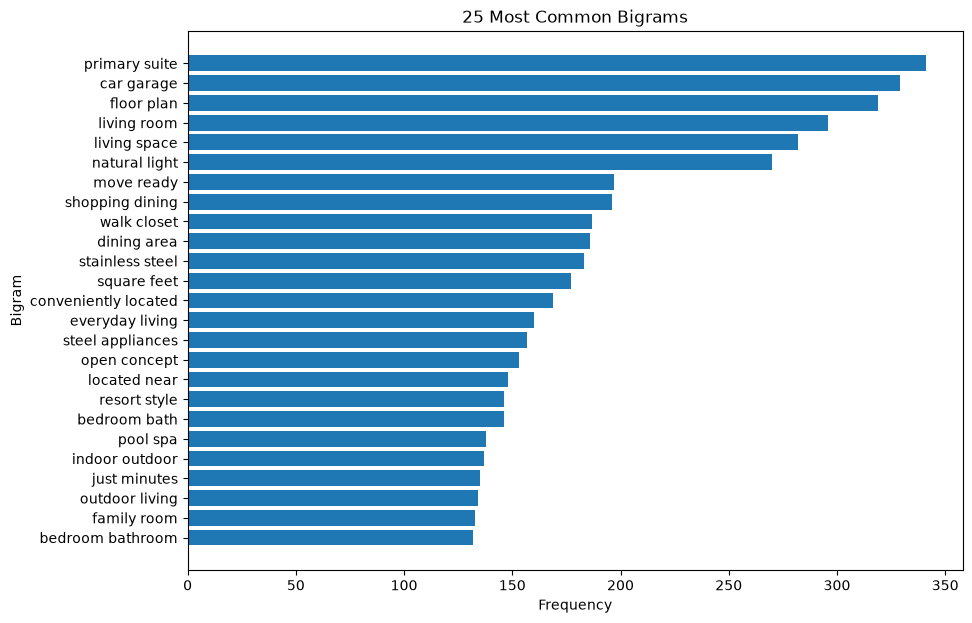

In [14]:
if "remarks" in df.columns:
    bigram_counter = Counter()

    for tokens in tokenized_remarks:
        bigram_counter.update(zip(tokens, tokens[1:]))

    top_bigrams = pd.DataFrame(
        [(" ".join(pair), count) for pair, count in bigram_counter.most_common(50)],
        columns=["bigram", "count"],
    )

    display(top_bigrams)

    if not top_bigrams.empty:
        plot_data = top_bigrams.head(25)
        plt.figure(figsize=(10, 7))
        plt.barh(plot_data["bigram"][::-1], plot_data["count"][::-1])
        plt.xlabel("Frequency")
        plt.ylabel("Bigram")
        plt.title("25 Most Common Bigrams")
        plt.show()


## 11. Price relationships

Explore whether bedroom and bathroom counts have visible relationships with listing price. These are descriptive sample-level relationships and should not be interpreted as causal.


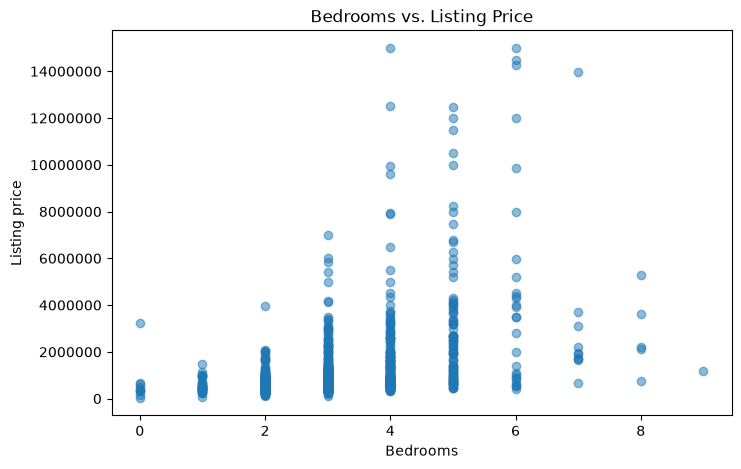

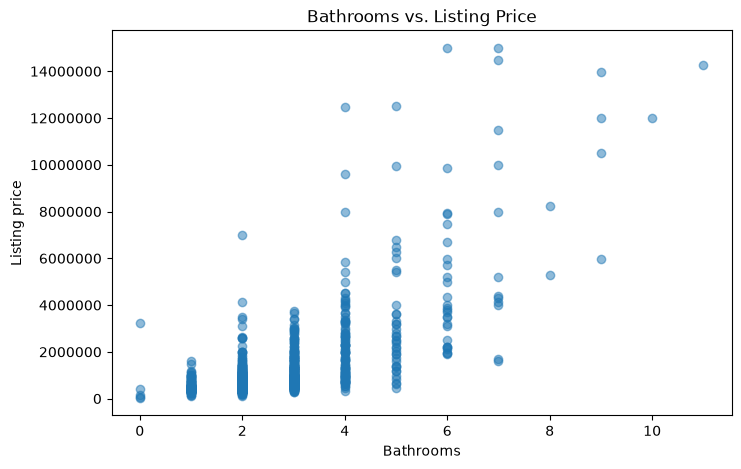

In [15]:
if all(c in df.columns for c in ["beds", "price"]):
    plot_df = df[["beds", "price"]].dropna()
    if not plot_df.empty:
        price_cap = plot_df["price"].quantile(0.99)
        plot_df = plot_df[(plot_df["price"] >= 0) & (plot_df["price"] <= price_cap)]

        plt.figure(figsize=(8, 5))
        plt.scatter(plot_df["beds"], plot_df["price"], alpha=0.5)
        plt.xlabel("Bedrooms")
        plt.ylabel("Listing price")
        plt.title("Bedrooms vs. Listing Price")
        plt.ticklabel_format(style="plain", axis="y")
        plt.show()

if all(c in df.columns for c in ["baths", "price"]):
    plot_df = df[["baths", "price"]].dropna()
    if not plot_df.empty:
        price_cap = plot_df["price"].quantile(0.99)
        plot_df = plot_df[(plot_df["price"] >= 0) & (plot_df["price"] <= price_cap)]

        plt.figure(figsize=(8, 5))
        plt.scatter(plot_df["baths"], plot_df["price"], alpha=0.5)
        plt.xlabel("Bathrooms")
        plt.ylabel("Listing price")
        plt.title("Bathrooms vs. Listing Price")
        plt.ticklabel_format(style="plain", axis="y")
        plt.show()


## 12. Numeric correlations


In [16]:
available = [c for c in ["beds", "baths", "price", "remark_length", "remark_word_count"] if c in df.columns]

if len(available) >= 2:
    display(df[available].corr(numeric_only=True).round(3))
else:
    print("Not enough numeric columns for correlation analysis.")


,beds,baths,price,remark_length,remark_word_count
beds,1.000,0.711,0.425,0.181,0.17
baths,0.711,1.000,0.694,0.257,0.24
price,0.425,0.694,1.000,0.160,0.15
remark_length,0.181,0.257,0.160,1.000,0.99
remark_word_count,0.170,0.240,0.150,0.990,1.00


## 13. Candidate taxonomy phrases

The following table saves the most frequent bigrams as candidates for manual review. Frequency alone is not enough to define a useful taxonomy: generic phrases should be removed, useful domain terms should be categorized, and important terms that are less frequent may need to be added manually.


In [17]:
if "remarks" in df.columns:
    taxonomy_candidates = pd.DataFrame(
        [(" ".join(pair), count) for pair, count in bigram_counter.most_common(200)],
        columns=["term", "frequency"],
    )

    display(taxonomy_candidates.head(50))

    candidate_path = Path("data/processed/taxonomy_candidates.csv")
    candidate_path.parent.mkdir(parents=True, exist_ok=True)
    taxonomy_candidates.to_csv(candidate_path, index=False)

    print(f"Saved {len(taxonomy_candidates)} candidates to {candidate_path}")


,term,frequency
0,primary suite,341
1,car garage,329
2,floor plan,319
3,living room,296
4,living space,282
5,natural light,270
6,move ready,197
7,shopping dining,196
8,walk closet,187
9,dining area,186


Saved 200 candidates to data/processed/taxonomy_candidates.csv
